In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Generate call duration data
np.random.seed(42)  # For reproducibility
call_durations = np.random.normal(
    loc=5, 
    scale=2, 
    size=1000
    )  

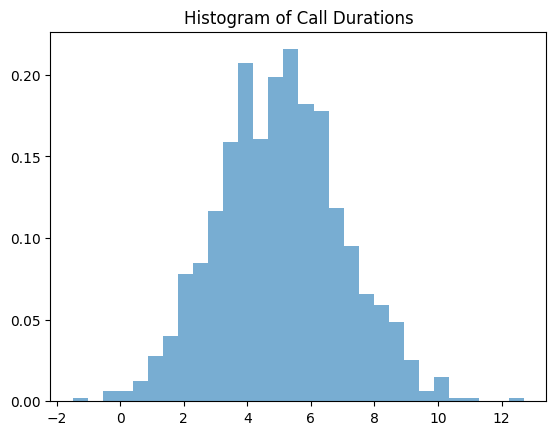

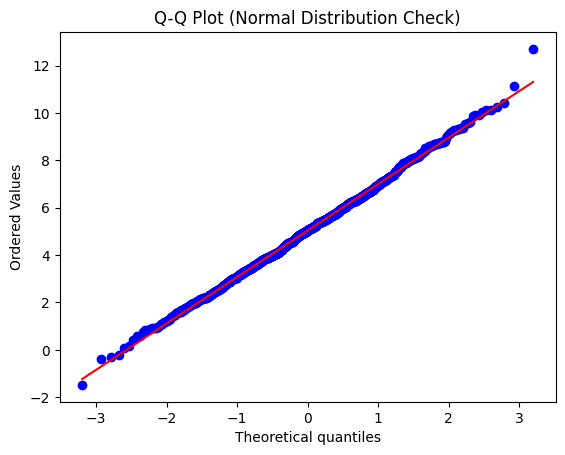

In [2]:
# Histogram
plt.figure()
plt.hist(call_durations, bins=30, density=True, alpha=0.6)
plt.title("Histogram of Call Durations")
plt.show()

# Q-Q plot against NORMAL distribution
plt.figure()
stats.probplot(call_durations, dist="norm", plot=plt)
plt.title("Q-Q Plot (Normal Distribution Check)")
plt.show()

In [3]:
mean = np.mean(call_durations)
std_dev = np.std(call_durations)

print(f"Mean: {mean:.2f}")
print(f"Standard Deviation: {std_dev:.2f}")

Mean: 5.04
Standard Deviation: 1.96


In [4]:
# Empirical Rule
one_sigma = (mean - std_dev, mean + std_dev)
two_sigma = (mean - 2*std_dev, mean + 2*std_dev)
three_sigma = (mean - 3*std_dev, mean + 3*std_dev)

print("Empirical Rule Intervals:")
print(f"1σ: {one_sigma}")
print(f"2σ: {two_sigma}")
print(f"3σ: {three_sigma}")

Empirical Rule Intervals:
1σ: (3.0812116961499427, 6.99611652713936)
2σ: (1.1237592806552343, 8.95356894263407)
3σ: (-0.833693134839474, 10.911021358128778)


In [5]:
n = len(call_durations)

pct_1 = (((call_durations >= one_sigma[0])   & (call_durations <= one_sigma[1])).sum()   / n) * 100
pct_2 = (((call_durations >= two_sigma[0])   & (call_durations <= two_sigma[1])).sum()   / n) * 100
pct_3 = (((call_durations >= three_sigma[0]) & (call_durations <= three_sigma[1])).sum() / n) * 100

print(f"\nActual % within 1σ: {pct_1:.2f}%")
print(f"Actual % within 2σ: {pct_2:.2f}%")
print(f"Actual % within 3σ: {pct_3:.2f}%")


Actual % within 1σ: 68.60%
Actual % within 2σ: 95.60%
Actual % within 3σ: 99.70%


In [6]:
# Calculating Z-score for a target call duration of 10 minutes
target_duration = 10
z_score = (target_duration - mean) / std_dev

# Calculate the probability of a call lasting more than 10 minutes
probability_more_than_target = 1 - stats.norm.cdf(z_score)

print(f"\nZ-score for target duration of {target_duration} minutes: {z_score:.2f}")
print(f"Probability of a call lasting more than {target_duration} minutes: {probability_more_than_target:.4f}")

# Use results to set realistic SLA targets.
sla_targets = {
    "68% of calls completed within": stats.norm.ppf(0.68, loc=mean, scale=std_dev),
    "95% of calls completed within": stats.norm.ppf(0.95, loc=mean, scale=std_dev),
    "99% of calls completed within": stats.norm.ppf(0.99, loc=mean, scale=std_dev),
}

print("\nRealistic SLA Targets:")
for label, duration in sla_targets.items():
    print(f"  {label}: {duration:.2f} minutes")



Z-score for target duration of 10 minutes: 2.53
Probability of a call lasting more than 10 minutes: 0.0056

Realistic SLA Targets:
  68% of calls completed within: 5.95 minutes
  95% of calls completed within: 8.26 minutes
  99% of calls completed within: 9.59 minutes


In [7]:
# Use mean duration to calculate service rate.
service_rate = 1 / mean  # calls per minute
# Consider call volume (calls per hour).
call_volume = 60  # example: 60 calls per hour

# Calculate minimum staff needed based on target occupancy.
target_occupancy = 0.85  # 85% occupancy
min_staff = call_volume / (service_rate * target_occupancy)
print(f"Minimum staff needed: {min_staff:.2f}")

Minimum staff needed: 355.67
